# Лабораторная работа 8

## Цель
Построить **прогноз на 8 месяцев** методом **сезонной декомпозиции** временного ряда

### Вариант 1
Коэффициент загрузки гостиниц в процентах (Hotel Occupancy (in %))
Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения процента занятых номеров за один день. Усреднение по отелям и по дням месяца
Данные расположены в столбце x1 файла Chicago_hotels.csv

**Период наблюдений:** январь 1994 — апрель 2003. **Прогноз:** май — декабрь 2003

### Идея метода
Ряд представляют в виде суммы **тренда** $T_t$, **сезонной** компоненты $S_t$ и **случайной** (остатка) $E_t$:

$$Y_t = T_t + S_t + E_t.$$

1. Оценивают $T_t$ и $S_t$ декомпозицией (здесь используется **STL** — устойчивая к выбросам процедура с явным периодом 12 месяцев)
2. Тренд экстраполируют линейной регрессией по времени
3. Сезонность для будущих месяцев берут как **среднюю по месяцам года** по уже оценённой сезонной компоненте
4. Остаток в простом прогнозе часто полагают нулевым в среднем: $\hat{E}_t = 0$

Тогда прогноз:

 $$\hat{Y}_{t+h} = \hat{T}_{t+h} + \hat{S}_{t+h}$$

## Загрузка данных и подготовка ряда

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["font.size"] = 11

DATA_PATH = "data.csv"

raw = pd.read_csv("data.csv", sep=";", encoding="utf-8")
raw["x1"] = pd.to_numeric(raw["x1"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
raw = raw.dropna(subset=["x1"]).copy()

raw["date"] = pd.to_datetime(
    raw["date1"].astype(str) + " " + raw["date2"].astype(str),
    format="%B %Y",
    errors="coerce",
)
raw = raw.dropna(subset=["date"]).sort_values("date")
series = raw.set_index("date")["x1"].asfreq("MS")  # начало месяца

print(f"Число наблюдений: {len(series)}")
print(f"С {series.index.min().date()} по {series.index.max().date()}")
series.head()

Число наблюдений: 112
С 1994-01-01 по 2003-04-01


date
1994-01-01    44.3
1994-02-01    54.7
1994-03-01    61.9
1994-04-01    69.1
1994-05-01    70.8
Freq: MS, Name: x1, dtype: float64

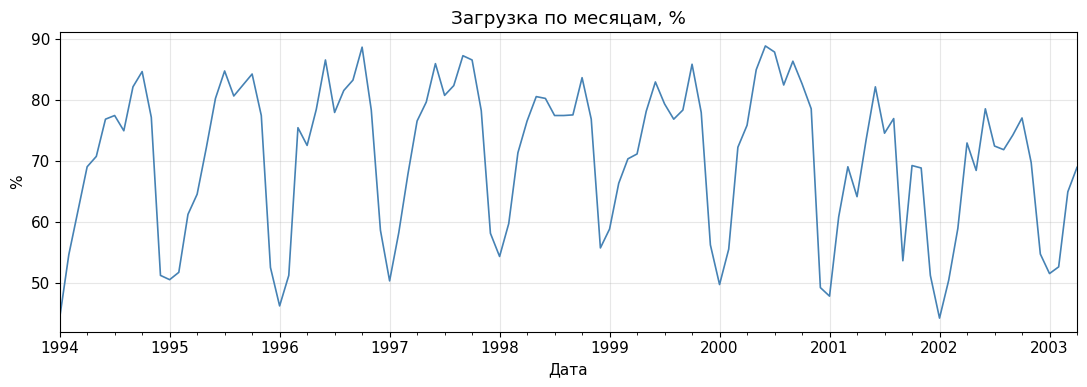

In [2]:
fig, ax = plt.subplots()
series.plot(ax=ax, color="steelblue", linewidth=1.2)
ax.set_title("Загрузка по месяцам, %")
ax.set_xlabel("Дата")
ax.set_ylabel("%")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Сезонная декомпозиция (STL)

STL выделяет тренд и сезонность при заданном **period=12**. Параметр `seasonal` (длина сглаживания сезонного фильтра) задаёт нечётным. Зададим 13 — стандартный выбор для месячных данных

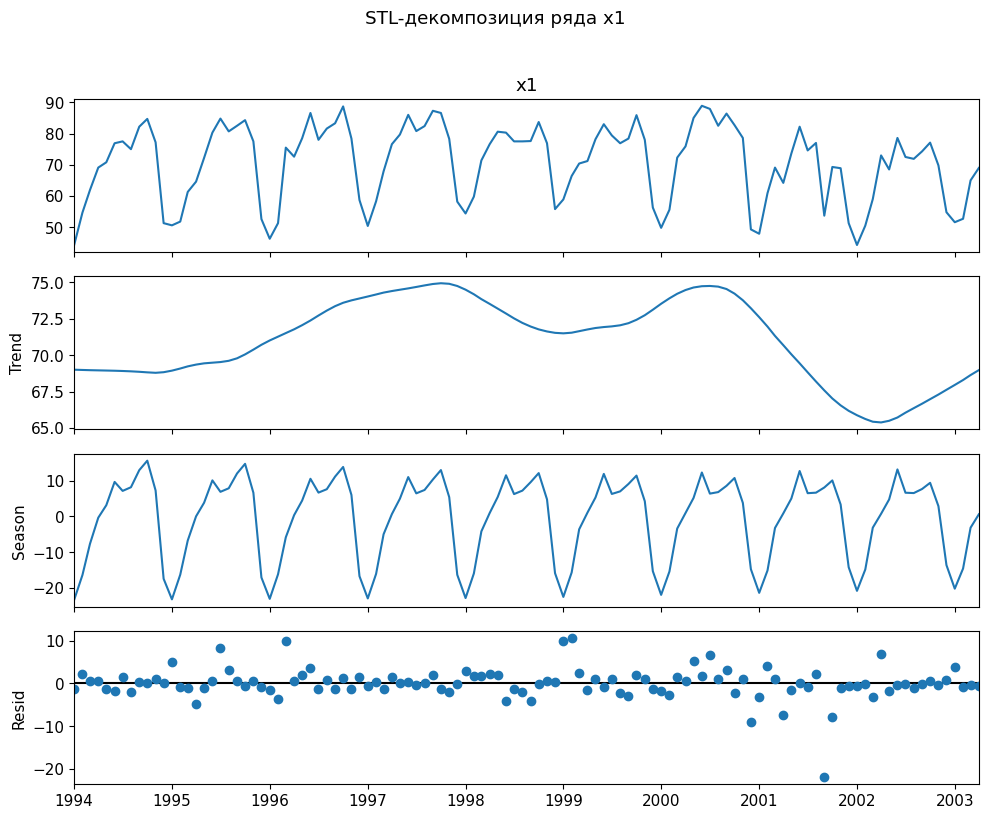

In [3]:
stl = STL(series, period=12, seasonal=13, robust=True)
decomp = stl.fit()

fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.suptitle("STL-декомпозиция ряда x1", y=1.02)
plt.tight_layout()
plt.show()

## Построение прогноза

- Тренд: линейная модель $\hat{T}_t = a + b\,t$, где $t$ — порядковый номер месяца; коэффициенты оцениваются по **оценённому** тренду STL на всей истории
- Сезонность для каждого календарного месяца — среднее значение сезонной компоненты STL по всем годам

In [4]:
trend = decomp.trend
seasonal = decomp.seasonal
resid = decomp.resid

decomp_df = pd.DataFrame({"y": series, "trend": trend, "seasonal": seasonal, "resid": resid})
decomp_df["month"] = decomp_df.index.month
seasonal_profile = decomp_df.groupby("month")["seasonal"].mean()

t_idx = np.arange(len(trend), dtype=float)
X = sm.add_constant(t_idx)
ols = sm.OLS(trend.values, X).fit()
a, b = ols.params

last_t = len(trend)
horizon = 8
future_t = np.arange(last_t , last_t  + horizon, dtype=float)
trend_future = a + b * future_t

last_date = series.index.max()
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
seasonal_future = future_dates.month.map(seasonal_profile).values

y_hat = trend_future + seasonal_future
forecast = pd.Series(y_hat, index=future_dates, name="forecast")

fc_table = pd.DataFrame({
    "дата": future_dates,
    "тренд": trend_future,
    "сезонность": seasonal_future,
    "прогноз_%": y_hat,
})
fc_table

,дата,тренд,сезонность,прогноз_%
0,2003-05-01,69.971487,4.709299,74.680786
1,2003-06-01,69.952646,11.495208,81.447854
2,2003-07-01,69.933805,6.624669,76.558473
3,2003-08-01,69.914964,7.302049,77.217013
4,2003-09-01,69.896123,9.999844,79.895967
5,2003-10-01,69.877282,12.394376,82.271657
6,2003-11-01,69.858441,4.961195,74.819636
7,2003-12-01,69.839600,-15.769729,54.069871


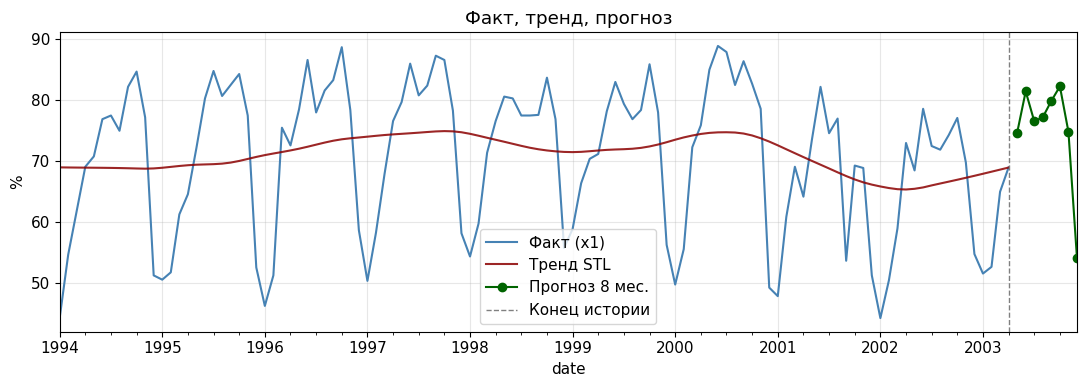

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
series.plot(ax=ax, label="Факт (x1)", color="steelblue")
decomp.trend.plot(ax=ax, label="Тренд STL", color="darkred", alpha=0.85)
forecast.plot(ax=ax, marker="o", label="Прогноз 8 мес.", color="darkgreen")
ax.axvline(last_date, color="gray", linestyle="--", linewidth=1, label="Конец истории")
ax.set_title("Факт, тренд, прогноз")
ax.set_ylabel("%")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Оценки качества

In [7]:
y_true = series
y_pred = (decomp.trend + decomp.seasonal)

df_q = (
    np.asarray(y_true).astype(float),
    np.asarray(y_pred).astype(float),
)

yt, yp = df_q

mae = float(np.mean(np.abs(yt - yp)))
rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))

den = np.abs(yt)
mask = den > 0
mape = float(np.mean(np.abs((yt[mask] - yp[mask]) / den[mask])) * 100) if np.any(mask) else float('nan')

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAPE = {mape:.2f}%")


MAE  = 2.2356
RMSE = 3.6863
MAPE = 3.39%


## Вывод:

Диапазон прогнозируемой загрузки: 54.07% - 82.27% 

Среднее значение загрузки: 75.12%

От последнего факта (69.00%) к первой точке прогноза: 74.68% (+5.68 п.п.)

Помесячно:

    2003-05: 74.68%

    2003-06: 81.45%

    2003-07: 76.56%

    2003-08: 77.22%

    2003-09: 79.90%

    2003-10: 82.27%

    2003-11: 74.82%

    2003-12: 54.07%
